## **Evaluación de la Transferencia de Aprendizaje**

Para comprobar la capacidad de generalización y transferencia de conocimiento que presentan los modelos (intra-dominio, unimodales, bimodales, y modelo sobre corpus unificado), se realiza en este notebook una evaluación de la transferencia de aprendizaje, que se dividide en 3 partes:

1. **Evaluación cruzada de los modelos intra-dominio**: Cada uno de los modelos intra-dominio se evalúan con el otro conjunto de datos completo, comprobando la transferencia de aprendizaje de los mismos.

2. **Evaluación frente a un tercer corpus (MSP-Improv)** del modelo final, los baselines unimodales, bimodales e intra-dominio. Todos estos modelos se enfrentan al dataset completo (**650 muestras**) de **MSP-Improv** (dataset independiente nunca antes visto por los modelos).

3. **Evaluación cruzada entre dominios de la arquitectura multimodal final**. Para comprobar la capacidad de generalización y transferencia de aprendizaje real del modelo final, se realiza una evaluación cruzada entre dominios. Esto consiste en rotar iterativamente los conjuntos de datos: con la misma arquitectura del modelo obtenido para MELD e IEMOCAP (fijando la misma configuración e hiperparámetros óptimos), se entrena este modelo desde cero rotando por las distintas combinaciones de datasets: MELD e IEMOCAP ya lo tenemos, falta MELD y MSP-IMPROV / IEMOCAP y MSP-IMPROV. Tras esto, estos modelos obtenidos se evalúan sobre el dataset restante, que se ha mantenido completamente invisible durante todo el entrenamiento. Se reporta finalmente el promedio de las métricas obtenidas de las distintas iteraciones en test. 
Al ir alternando el corpus excluido en distintas iteraciones, se aísla el rendimiento del sistema de los sesgos ambientales, acústicos o de guion presentes a una base de datos específica. De esta forma, se demuestra empíricamente si el modelo es capaz de extraer representaciones universales del estrés y transferir el conocimiento aprendido a entornos e individuos del mundo real totalmente nuevos.

In [45]:
import subprocess
import os
import torch
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = os.path.expanduser('/workspace')
csv_path = os.path.join(BASE_DIR, 'MSP-Improv_clean.csv')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entorno de ejecución configurado en: {device}")

Entorno de ejecución configurado en: cuda


In [46]:
def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, Balanced Accuracy, el ROC-AUC y el Recall de la clase 'Estrés'
    """
    f1_macro = 0.0
    auc = 0.0
    ba = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "Balanced Accuracy" in linea:
            ba = float(linea.split(":")[1].strip())
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, ba, auc, recall_estres

----
## **1. Evaluación cruzada de los modelos intra-dominio**

* **Modelo entrenado sobre MELD evaluado en el dataset de IEMOCAP**:

In [19]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
           f"--transfer_learning IEMOCAP ") ##########
                        
subprocess.run(comando, shell=True)

100%|██████████| 7515/7515 [00:35<00:00, 213.27it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.48 ms / muestra
ROC-AUC Score: 0.6834
F1 Macro: 0.5158
F1 Weighted: 0.5672
Accuracy (en %): 64.62%
Balanced Accuracy (en %): 56.35%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 --transfer_learning IEMOCAP ', returncode=0)

* **Modelo entrenado sobre IEMOCAP evaluado en el dataset de MELD**:

In [20]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--transfer_learning MELD ") #######
                        
subprocess.run(comando, shell=True)

100%|██████████| 13704/13704 [01:02<00:00, 220.74it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.36 ms / muestra
ROC-AUC Score: 0.5658
F1 Macro: 0.5268
F1 Weighted: 0.7560
Accuracy (en %): 74.50%
Balanced Accuracy (en %): 53.06%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --transfer_learning MELD ', returncode=0)

A continuación, se muestra una gráfica y tabla para llevar a cabo la comparativa del rendimiento obtenido de los modelos intra-dominio de forma cruzada y con respecto a MSP-Improv.

----
## **2. Evaluación frente a un tercer corpus (MSP-Improv)**

### **1. Baselines Unimodales**

* **ResNet**:
    * **Ventana**: 32 frames
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 256, `hidden_mlp` = 64
        * **Dropout**: 0.3
        * **Learning Rate**: 1e-05

100%|██████████| 650/650 [00:00<00:00, 691.16it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 5,396,481
Parámetros Entrenables: 5,396,481
Tiempo medio de Inferencia: 0.79 ms / muestra
ROC-AUC Score: 0.4839
F1 Macro: 0.4769
F1 Weighted: 0.6790
Accuracy (en %): 74.92%
Balanced Accuracy (en %): 50.88%


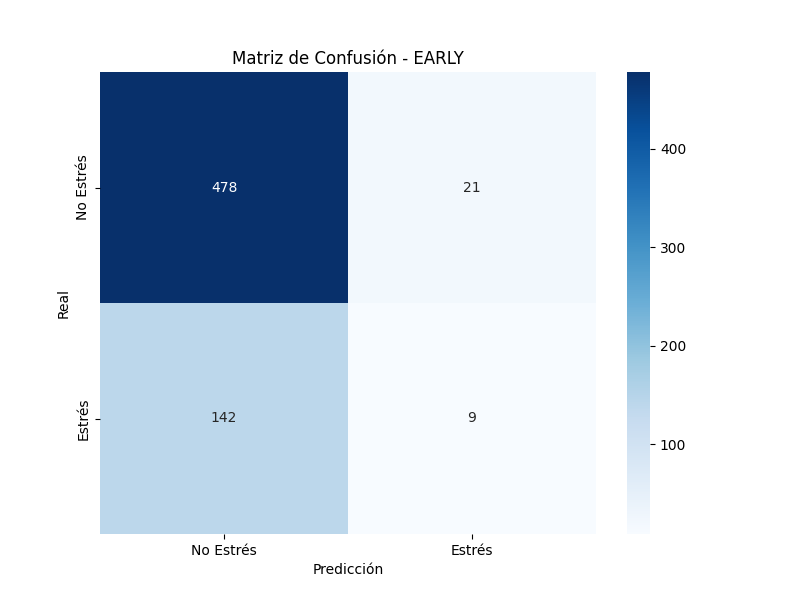

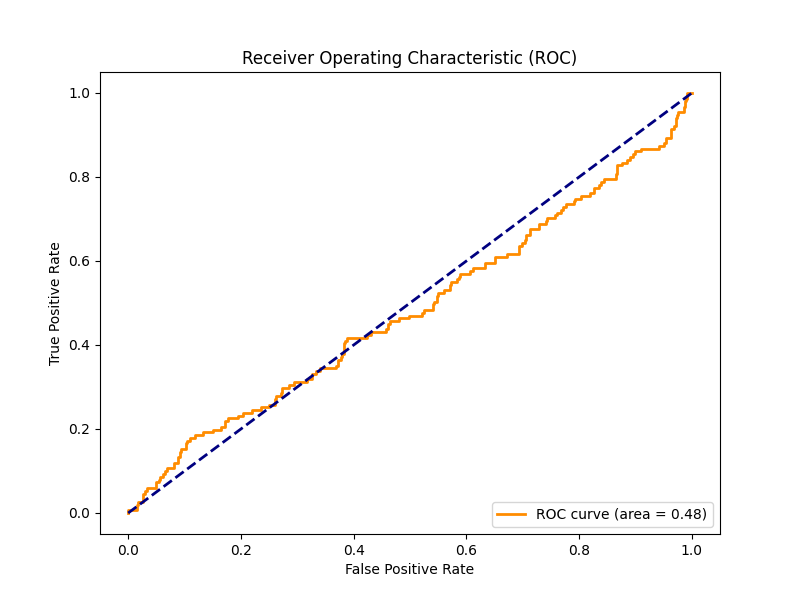

In [8]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_video_resnet_ventana32_pdim256_hmlp64_do0.3_lr1e-05.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--video resnet "
        f"--video_frames 32 "
        f"--proj_dim 256 "
        f"--hidden_mlp 64 "
        f"--dropout 0.3 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_VIDEO_resnet_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_VIDEO_resnet_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **Wav2Vec 2.0**:
    * **Ventana**: 7 segundos
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 512, `hidden_mlp` = 128
        * **Dropout**: 0.3
        * **Learning Rate**: 0.0001

100%|██████████| 650/650 [00:03<00:00, 173.16it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 2,956,289
Parámetros Entrenables: 2,956,289
Tiempo medio de Inferencia: 4.38 ms / muestra
ROC-AUC Score: 0.4759
F1 Macro: 0.4338
F1 Weighted: 0.6660
Accuracy (en %): 76.62%
Balanced Accuracy (en %): 49.90%


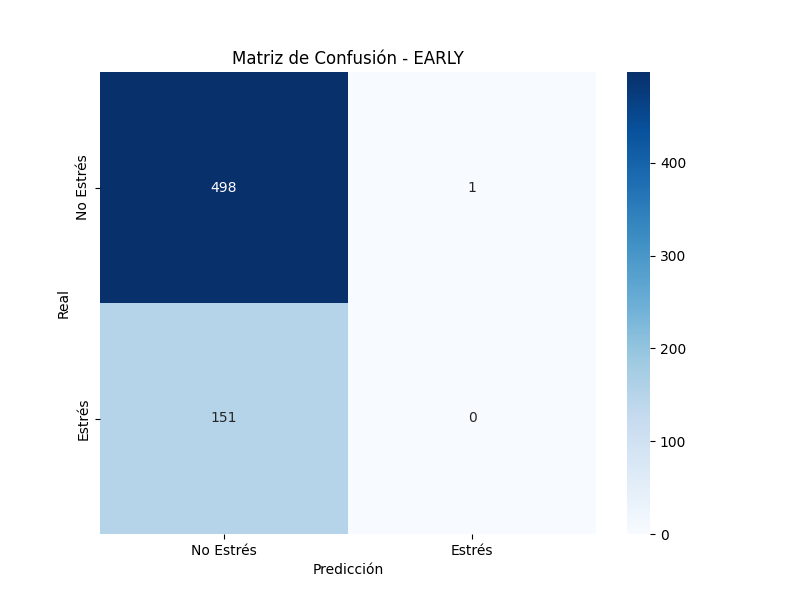

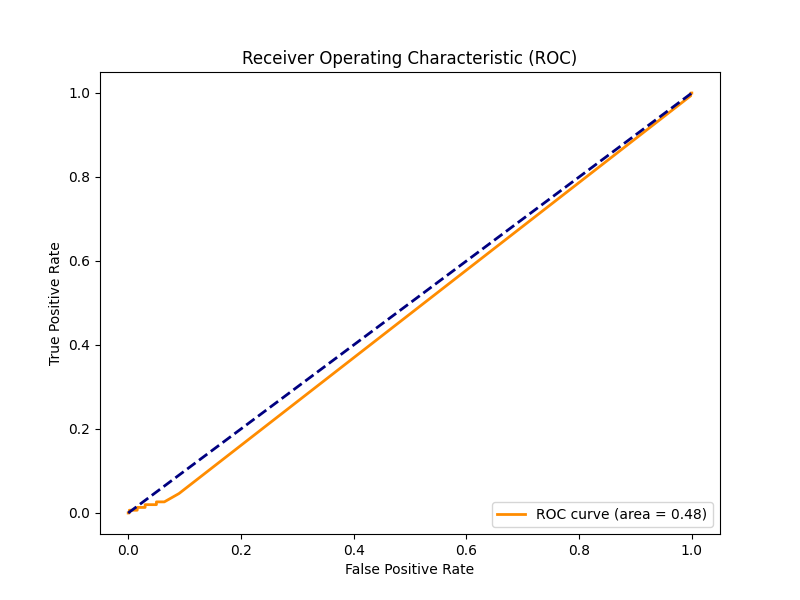

In [10]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_audio_wav2vec_ventana7_pdim512_hmlp128_do0.3_lr0.0001.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--audio wav2vec "
        f"--audio_len 7 "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.3 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_AUDIO_wav2vec_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_AUDIO_wav2vec_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **RoBERTa**:
    * **Ventana**: 64 tokens
    * **Arquitectura**:
        * Red pequeña: `proj_dim` = 512, `hidden_mlp` = 128
        * **Dropout**: 0.3
        * **Learning Rate**: 5e-05

100%|██████████| 650/650 [00:00<00:00, 741.13it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 460,801
Parámetros Entrenables: 460,801
Tiempo medio de Inferencia: 0.52 ms / muestra
ROC-AUC Score: 0.5886
F1 Macro: 0.5678
F1 Weighted: 0.6824
Accuracy (en %): 67.38%
Balanced Accuracy (en %): 57.28%


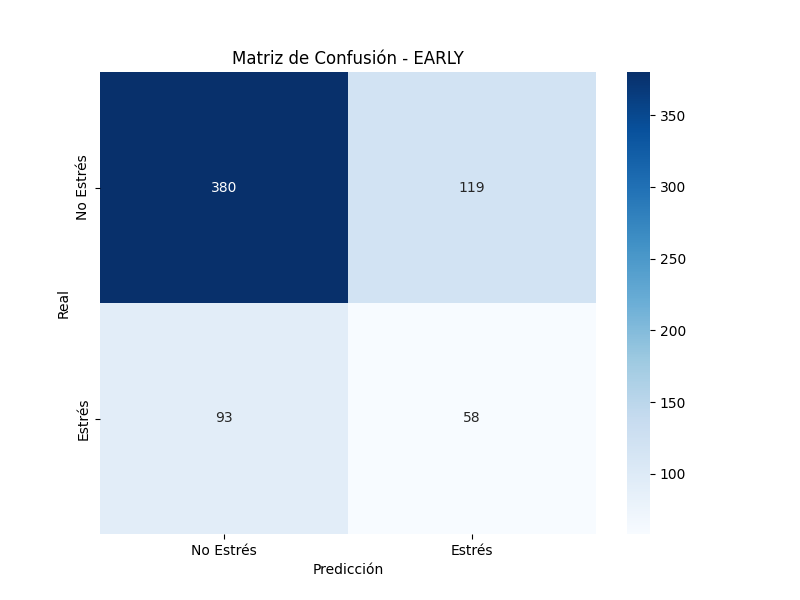

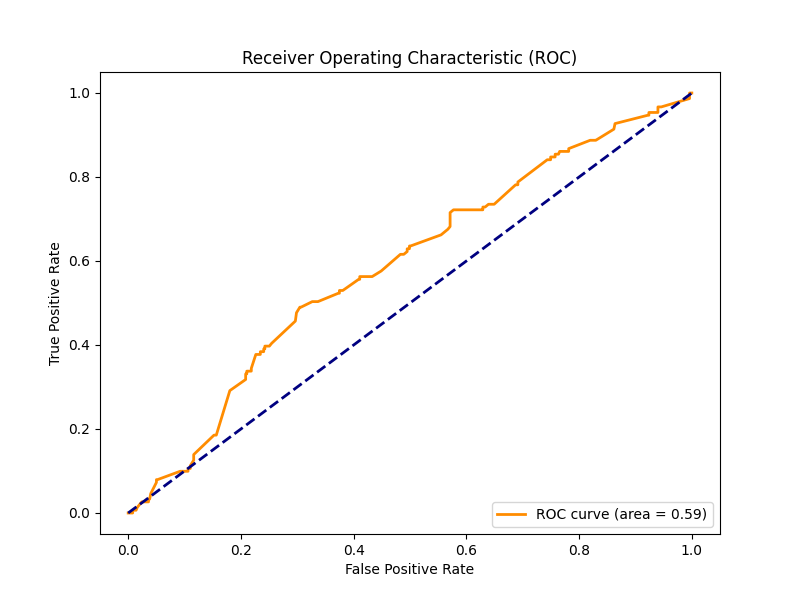

In [23]:
path_pesos = "pesos/unimodales_ajuste/pesos_baseline_unimodal_texto_roberta64_ventana64_pdim512_hmlp128_do0.3_lr5e-05.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--text roberta64 "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.3 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_confusion_baseline_unimodal_TEXTO_roberta64_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_curva_roc_baseline_unimodal_TEXTO_roberta64_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

### **2. Baselines Bimodales**

* **Vídeo + Audio**:

100%|██████████| 650/650 [00:03<00:00, 174.13it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 6,530,565
Parámetros Entrenables: 6,530,565
Tiempo medio de Inferencia: 4.34 ms / muestra
ROC-AUC Score: 0.4534
F1 Macro: 0.4333
F1 Weighted: 0.6653
Accuracy (en %): 76.46%
Balanced Accuracy (en %): 49.80%


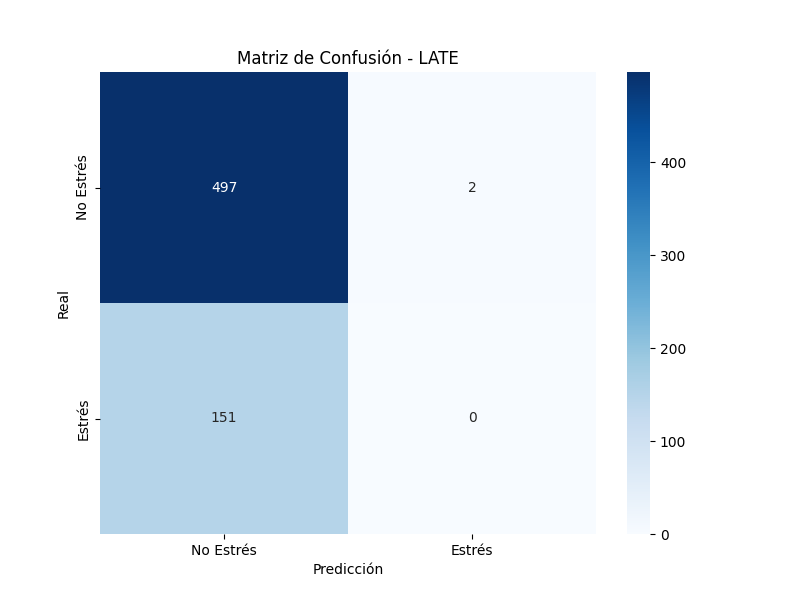

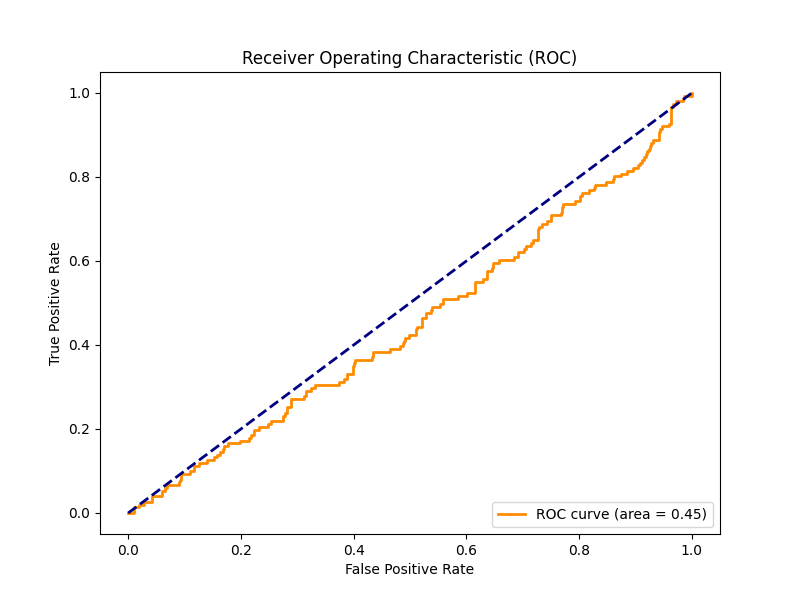

In [12]:
path_pesos = "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--fusion late "
        f"--late_mode logistica "
        f"--video resnet "
        f"--audio wav2vec "
        f"--proj_dim 256 "
        f"--hidden_mlp 64 "
        f"--dropout 0.3 "
        f"--video_frames 16 "
        f"--audio_len 7 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **Vídeo + Texto**:

100%|██████████| 650/650 [00:01<00:00, 383.78it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 6,038,533
Parámetros Entrenables: 6,038,533
Tiempo medio de Inferencia: 1.41 ms / muestra
ROC-AUC Score: 0.5696
F1 Macro: 0.4544
F1 Weighted: 0.6719
Accuracy (en %): 75.69%
Balanced Accuracy (en %): 50.22%


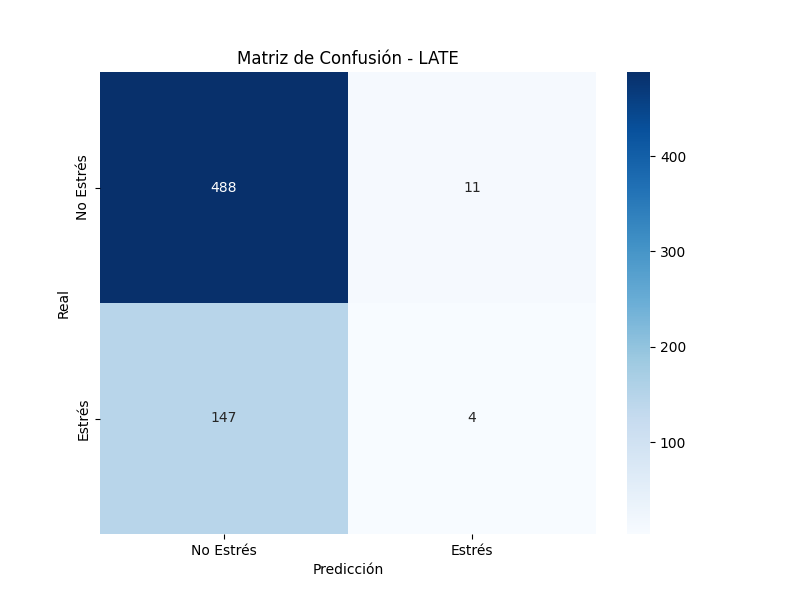

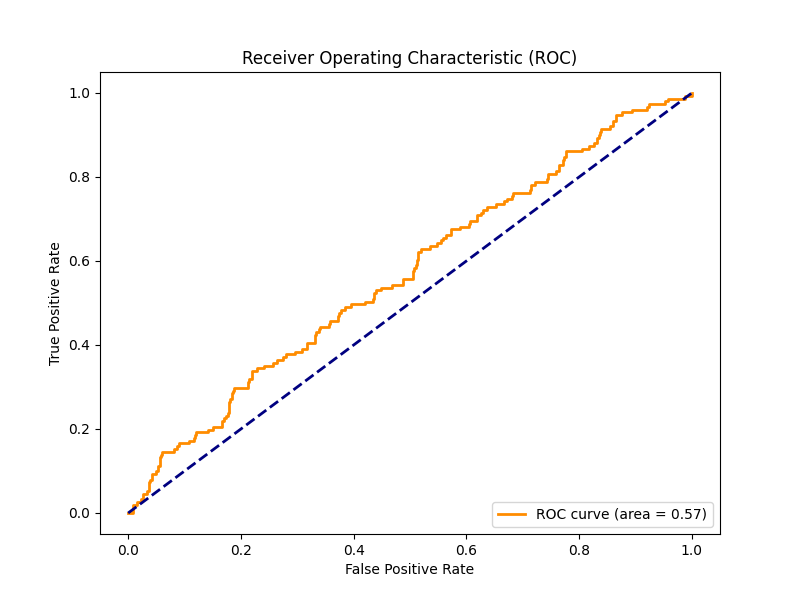

In [13]:
path_pesos = "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--fusion late "
        f"--late_mode logistica "
        f"--video resnet "
        f"--text roberta64 "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.5 "
        f"--video_frames 32 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **Audio + Texto**:

100%|██████████| 650/650 [00:03<00:00, 178.34it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 3,417,090
Parámetros Entrenables: 3,417,090
Tiempo medio de Inferencia: 4.28 ms / muestra
ROC-AUC Score: 0.5511
F1 Macro: 0.4931
F1 Weighted: 0.6321
Accuracy (en %): 62.62%
Balanced Accuracy (en %): 49.33%


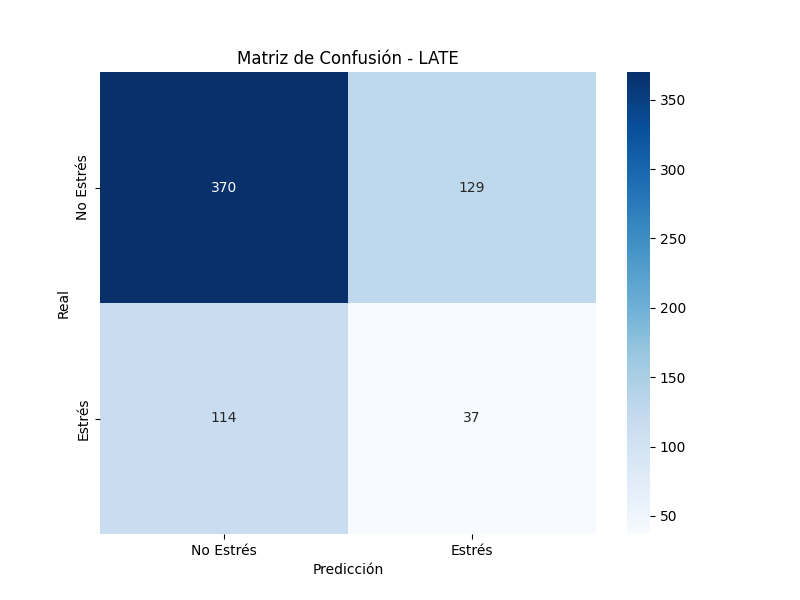

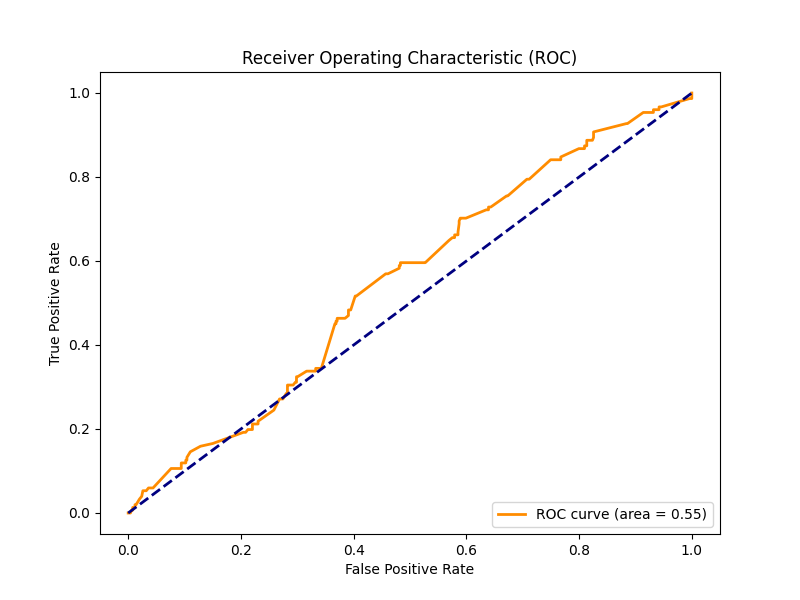

In [14]:
path_pesos = "pesos/bimodales_ajuste/pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3.pth"
comando = (
        f"python evaluate.py "
        f"--model_path {path_pesos} "
        f"--fusion late "
        f"--late_mode promedio "
        f"--text roberta64 "
        f"--audio wav2vec "
        f"--proj_dim 512 "
        f"--hidden_mlp 128 "
        f"--dropout 0.3 "
        f"--audio_len 7 "
        f"--transfer_learning MSP-IMPROV " ###
    )

_ = subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

### **3. Modelos Intra-dominio**

* **Modelo entrenado en MELD**: 

100%|██████████| 650/650 [00:03<00:00, 185.42it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 4.10 ms / muestra
ROC-AUC Score: 0.5761
F1 Macro: 0.4858
F1 Weighted: 0.6629
Accuracy (en %): 69.85%
Balanced Accuracy (en %): 49.65%


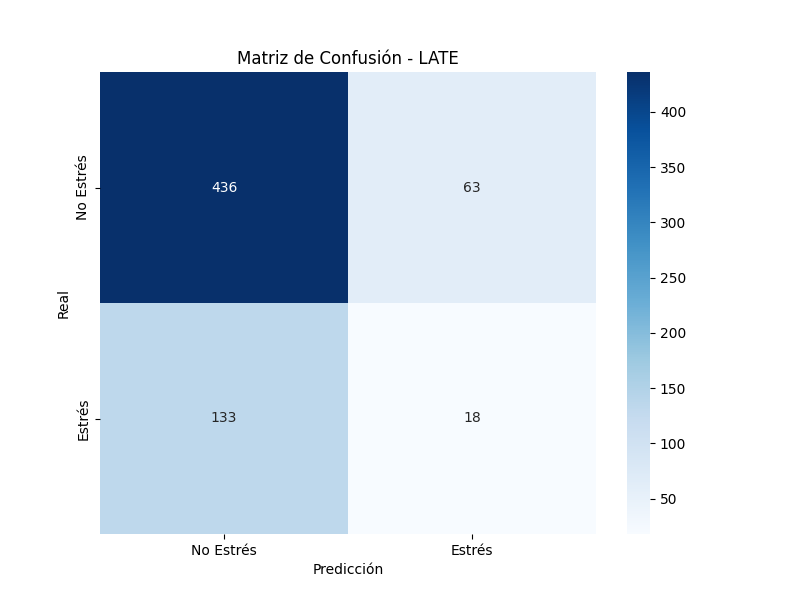

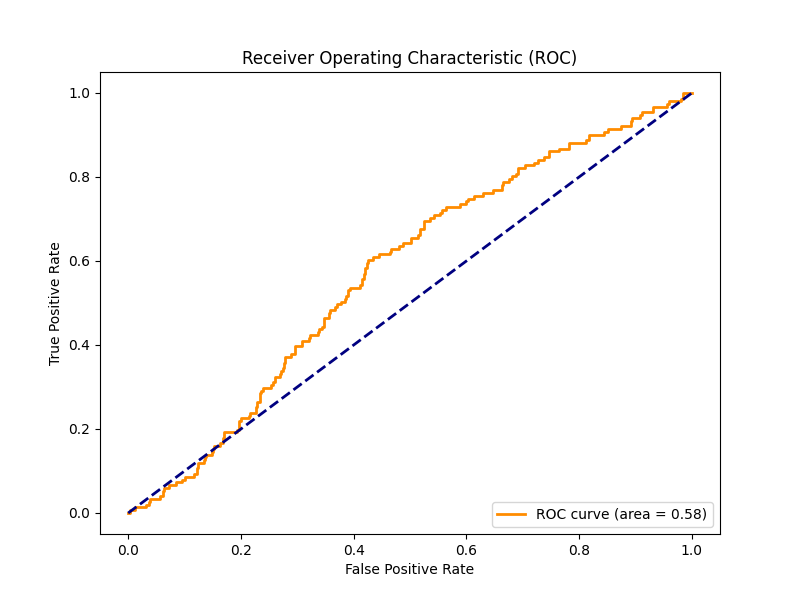

In [17]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
          f"--transfer_learning MSP-IMPROV ") ###
                        
subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

* **Modelo entrenado en IEMOCAP**: 

100%|██████████| 650/650 [00:03<00:00, 182.83it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 4.14 ms / muestra
ROC-AUC Score: 0.5466
F1 Macro: 0.3876
F1 Weighted: 0.3907
Accuracy (en %): 38.77%
Balanced Accuracy (en %): 53.65%


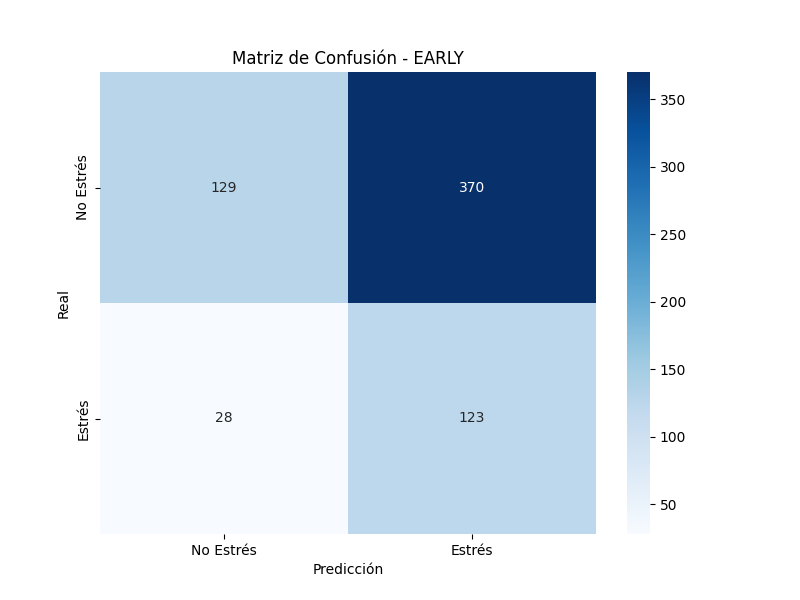

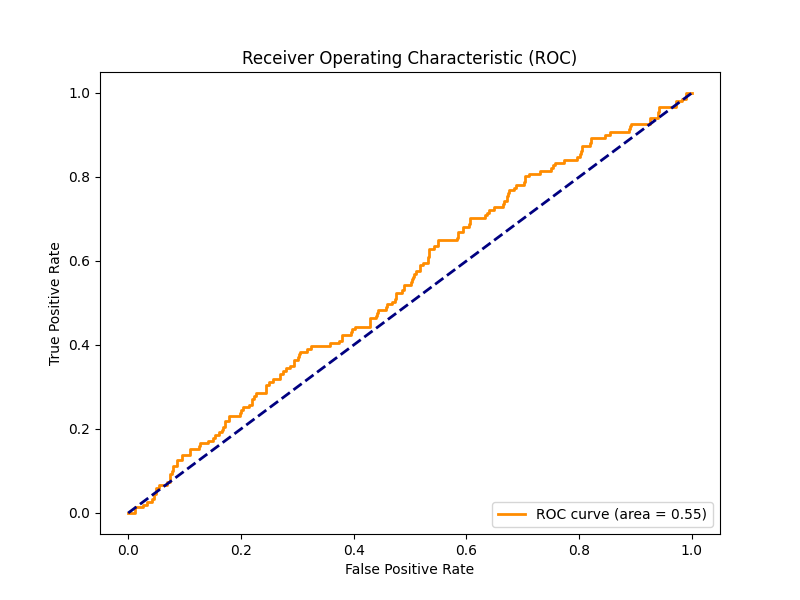

In [18]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
          f"--transfer_learning MSP-IMPROV ") ###
                        
subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_transfer_learning_MSP-IMPROV.png"

# Mostrar la imagen
display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

Figura y tabla comparativo modelos intra-dominio sobre MSP-IMPROV y de forma cruzada:

,Modelo Entrenado,Test MELD,Test IEMOCAP,Test MSP-IMPROV
0,Intra-dominio (Solo MELD),0.6664,0.5158,0.4858
1,Intra-dominio (Solo IEMOCAP),0.5268,0.6860,0.3876


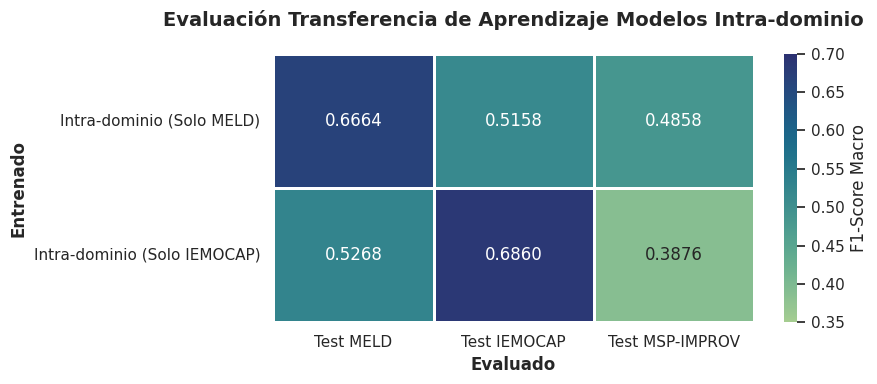

In [27]:
datos_transfer = {
    'Modelo Entrenado': ['Intra-dominio (Solo MELD)', 'Intra-dominio (Solo IEMOCAP)'],
    'Test MELD': [0.6664, 0.5268],                
    'Test IEMOCAP': [0.5158, 0.6860],             
    'Test MSP-IMPROV': [0.4858, 0.3876] 
}

df_transfer = pd.DataFrame(datos_transfer)


df_transfer.to_csv('tabla_transfer_intradominio.csv', index=False)
display(df_transfer.style.background_gradient(cmap='Blues', axis=1).format(precision=4))

df_heatmap = df_transfer.set_index('Modelo Entrenado')

plt.figure(figsize=(9, 4))
sns.set_theme(style="white")

mapa = sns.heatmap(
    df_heatmap, 
    annot=True,          
    fmt=".4f",           
    cmap="crest",        
    vmin=0.35, vmax=0.70, 
    linewidths=1,        
    cbar_kws={'label': 'F1-Score Macro'}
)

plt.title('Evaluación Transferencia de Aprendizaje Modelos Intra-dominio', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Entrenado', fontsize=12, fontweight='bold')
plt.xlabel('Evaluado', fontsize=12, fontweight='bold')

plt.yticks(rotation=0, fontsize=11)
plt.xticks(fontsize=11)

plt.tight_layout()
plt.savefig('Fig_heatmap_transfer_intradominio.png', dpi=300, bbox_inches='tight')
plt.show()

Se observa que el rendimiento cae cuando los modelos intra-dominio son evaluados en datasets distintos, ya sea de forma cruzada o con MSP-IMPROV, siendo este último en el que peor rinden ambos modelos. Esto indica, por tanto, que este dataset es distinto con respecto a MELD e IEMOCAP y al modelo le es más díficil detectar las muestres de estrés en él. 

### **4. Arquitectura mutlimodal entrenada sobre Corpus Global (Modelo Final)**

* **Corpus Global Unificado (MELD + IEMOCAP)**: 
    * Arquitectura de Fusión mediante Atención:
        - **Ventana de Vídeo**: 32 frames
        - **Ventana de Audio**: 7 segundos
        - **Ventana de Texto**: 32 tokens
        - **proj_dim**: 512 y **hidden_mlp**: 128 (Red Grande)
        - **Learning Rate**: 5e-05
        - **Dropout**: 0.3

100%|██████████| 650/650 [00:03<00:00, 170.41it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 4.39 ms / muestra
ROC-AUC Score: 0.5611
F1 Macro: 0.5363
F1 Weighted: 0.6398
Accuracy (en %): 61.69%
Balanced Accuracy (en %): 55.19%


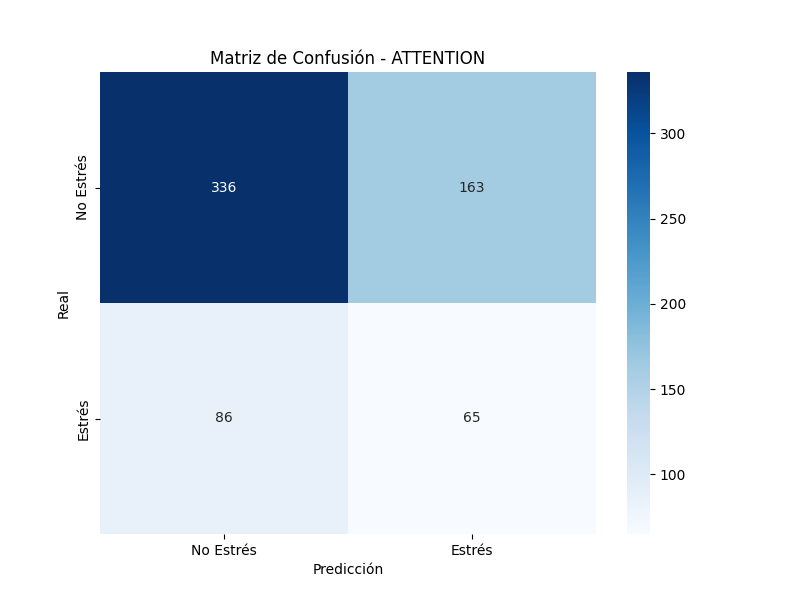

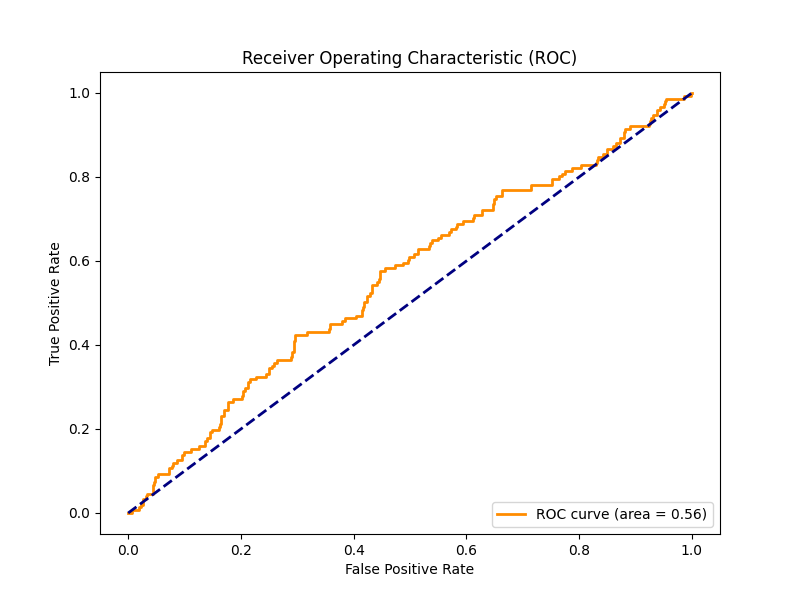

In [21]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--transfer_learning MSP-IMPROV ") ####
                        
subprocess.run(comando, shell=True)

nombre_archivo_mc = "Fig_matriz_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.png"
nombre_archivo_roc = "Fig_roc_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.png"

display(Image(filename=nombre_archivo_mc))
display(Image(filename=nombre_archivo_roc))

------
## **Figura Comparativa Final Resultados en MSP-IMPROV**

,Modelo,F1-Macro,Balanced Accuracy,ROC-AUC,Recall (Estrés)
0,Unimodal Texto (RoBERTa),0.5678,0.5728,0.5886,0.3841
1,Global Final,0.5363,0.5519,0.5611,0.4305
2,Bimodal Audio y Texto,0.4931,0.4933,0.5511,0.2450
3,Intra MELD,0.4858,0.4965,0.5761,0.1192
4,Unimodal Vídeo (ResNet),0.4769,0.5088,0.4839,0.0596
5,Bimodal Vídeo y Texto,0.4544,0.5022,0.5696,0.0265
6,Unimodal Audio (Wav2Vec),0.4338,0.4990,0.4759,0.0000
7,Bimodal Vídeo y Audio,0.4333,0.4980,0.4534,0.0000
8,Intra IEMOCAP,0.3876,0.5365,0.5466,0.8146


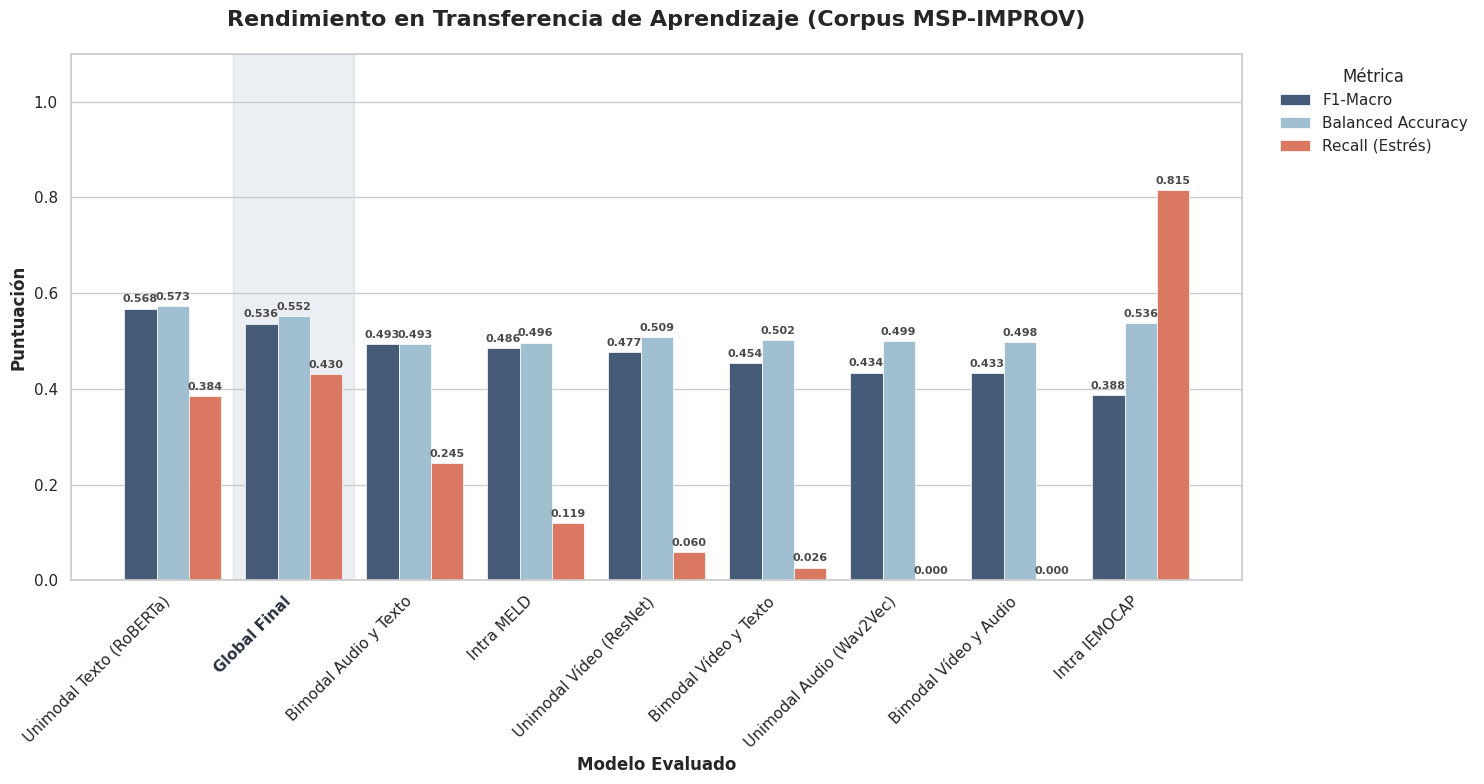

In [49]:
archivos_modelos = {
    'Unimodal Vídeo (ResNet)': 'resultados/transfer_learning/unimodales/reporte_final_baseline_unimodal_VIDEO_resnet_transfer_learning_MSP-IMPROV.txt',
    'Unimodal Audio (Wav2Vec)': 'resultados/transfer_learning/unimodales/reporte_final_baseline_unimodal_AUDIO_wav2vec_transfer_learning_MSP-IMPROV.txt',
    'Unimodal Texto (RoBERTa)': 'resultados/transfer_learning/unimodales/reporte_final_baseline_unimodal_TEXTO_roberta64_transfer_learning_MSP-IMPROV.txt',
    'Bimodal Vídeo y Audio': 'resultados/transfer_learning/bimodales/reporte_pesos_modelo_estres_global_late_logistica_resnet16_wav2vec7s_p256_h64_lr1e-05_do0.3_transfer_learning_MSP-IMPROV.txt',
    'Bimodal Vídeo y Texto': 'resultados/transfer_learning/bimodales/reporte_pesos_modelo_estres_global_late_logistica_resnet32_roberta64_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.txt',
    'Bimodal Audio y Texto': 'resultados/transfer_learning/bimodales/reporte_pesos_modelo_estres_global_late_promedio_wav2vec7s_roberta64_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.txt',
    'Intra MELD': 'resultados/transfer_learning/intra/MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_transfer_learning_MSP-IMPROV.txt',
    'Intra IEMOCAP': 'resultados/transfer_learning/intra/IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_transfer_learning_MSP-IMPROV.txt',
    'Global Final': 'resultados/transfer_learning/inter_multimodal/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.txt'
}

datos_msp = []
for modelo, ruta in archivos_modelos.items():
    f1, ba, auc, recall = extraer_metricas_txt(ruta)
    datos_msp.append([modelo, f1, ba, auc, recall])


columnas = ['Modelo', 'F1-Macro', 'Balanced Accuracy', 'ROC-AUC', 'Recall (Estrés)']
df_msp = pd.DataFrame(datos_msp, columns=columnas)

# Ordenamos por F1-Macro
df_msp = df_msp.sort_values(by='F1-Macro', ascending=False).reset_index(drop=True)

df_msp.to_csv('tabla_resultados_MSP_IMPROV_completa.csv', index=False)
display(df_msp.style.background_gradient(cmap='Blues', subset=['F1-Macro', 'Balanced Accuracy', 'ROC-AUC', 'Recall (Estrés)']).format(precision=4))


# Filtramos solo las métricas de F1-Macro y Balanced Accuracy
df_grafica = df_msp[['Modelo', 'F1-Macro', 'Balanced Accuracy', 'Recall (Estrés)']]
df_melted = df_grafica.melt(id_vars='Modelo', var_name='Métrica', value_name='Puntuación')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8))

colores_elegantes = ['#3D5A80', '#98C1D9', '#EE6C4D'] 

ax = sns.barplot(
    data=df_melted, 
    x='Modelo', 
    y='Puntuación', 
    hue='Métrica', 
    palette=colores_elegantes,
    edgecolor='white', 
    linewidth=0.5
)

etiquetas_x = [t.get_text() for t in ax.get_xticklabels()]
if 'Global Final' in etiquetas_x:
    idx_final = etiquetas_x.index('Global Final')

    ax.axvspan(idx_final - 0.5, idx_final + 0.5, color='#3D5A80', alpha=0.10, zorder=0)

    for tick in ax.get_xticklabels():
        if tick.get_text() == 'Global Final':
            tick.set_fontweight('bold')
            tick.set_color('#293241') 

plt.title('Rendimiento en Transferencia de Aprendizaje (Corpus MSP-IMPROV)', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1.1) 
plt.ylabel('Puntuación', fontsize=12, fontweight='bold')
plt.xlabel('Modelo Evaluado', fontsize=12, fontweight='bold')

# Rotación para legibilidad:
plt.xticks(rotation=45, ha='right', fontsize=11)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8, color='#4a4a4a', fontweight='bold')

plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False) 

plt.tight_layout()
nombre_grafica = 'Fig_Resultados_MSP_IMPROV_Ordenada.png'
plt.savefig(nombre_grafica, dpi=300, bbox_inches='tight')

plt.show()

Claramente, todas las métricas se desploman en comparación con test del dataset correspondiente, indicando que la naturaleza de este corpus es diferente a MELD e IEMOCAP, presentando el modelo mayores dificultades para la tarea. En la gráfica, se observa ordenada por F1-Score Macro, siendo el mejor modelo el primero a la izquierda, **baseline unimodal de RoBERTa**. El modelo global final multimodal entrenado sobre MELD e IEMOCAP queda en segunda posición, pero es revelador lo que se muestra en el recall en ambos. Para el baseline de RoBERTa, el recall se desploma, por tanto, el modelo no consigue detectar la mayor parte (más del 60%) de las muestras de estrés, mientras que el modelo final global sí consigue mantener mayor estabilidad y detectar mejor las muestras de estrés, presentando mayor recall. 

------
## **Evaluación cruzada entre dominios de la arquitectura multimodal final**

Entrenamos rotando los diferentes corpus de entrenamiento, y evaluamos con el dataset faltante no visto por el modelo durante su entrenamiento. Tras obtener los resultados en evaluación de transferencia de aprendizaje en cada iteración, reportamos finalmente el promedio para obtener la capacidad real de generalización y transferencia de conocimiento de la arquitectura multimodal final. 

1. **Entrenamiento: MSP-IMPROV y MELD**

In [35]:
comando = (f"python train.py "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--lr 5e-05 "
           f"--dropout 0.3 "
           f"--transfer_learning MELD_MSP-IMPROV ")
                        
subprocess.run(comando, shell=True)

Epoch 1/20:   0%|          | 0/325 [00:00<?, ?it/s]

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 325/325 [00:17<00:00, 18.71it/s, loss=0.904]


Epoch 1. Train Loss: 1.0936. Val Loss: 1.1419. Val F1 Macro: 0.5660. Val Recall Estrés: 0.8008

Nuevo mejor modelo: (F1: 0.5660) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 325/325 [00:17<00:00, 18.51it/s, loss=0.827]


...

Epoch 17/20: 100%|██████████| 325/325 [00:17<00:00, 18.39it/s, loss=0.286]


Epoch 17. Train Loss: 0.3225. Val Loss: 1.5507. Val F1 Macro: 0.5870. Val Recall Estrés: 0.6349

Sin mejora en F1-Score. Límite: 4/5


Epoch 18/20: 100%|██████████| 325/325 [00:18<00:00, 17.91it/s, loss=0.357] 


Epoch 18. Train Loss: 0.2975. Val Loss: 2.0697. Val F1 Macro: 0.6269. Val Recall Estrés: 0.3776

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 18 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.json


CompletedProcess(args='python train.py --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --lr 5e-05 --dropout 0.3 --transfer_learning MELD_MSP-IMPROV ', returncode=0)

Lo evaluamos en IEMOCAP: 

In [37]:
path_pesos = "pesos/transfer_learning/pesos_modelo_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--transfer_learning IEMOCAP ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 7515/7515 [00:35<00:00, 209.97it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.52 ms / muestra
ROC-AUC Score: 0.6287
F1 Macro: 0.4311
F1 Weighted: 0.4978
Accuracy (en %): 61.73%
Balanced Accuracy (en %): 52.20%


CompletedProcess(args='python evaluate.py --model_path pesos/transfer_learning/pesos_modelo_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --transfer_learning IEMOCAP ', returncode=0)

2. **Entrenamiento: MSP-IMPROV e IEMOCAP**

In [38]:
comando = (f"python train.py "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--lr 5e-05 "
           f"--dropout 0.3 "
           f"--transfer_learning IEMOCAP_MSP-IMPROV ")
                        
subprocess.run(comando, shell=True)

DETECCIÓN DE ESTRÉS: 
--> Fusión: ATTENTION
--> Vídeo: resnet (32 frames) -> EMBEDDINGS_VISUAL
--> Audio: wav2vec (7s -> 350 pasos) -> EMBEDDINGS_AUDIO
--> Texto: roberta32 -> EMBEDDINGS_TEXTO


Epoch 1/20: 100%|██████████| 154/154 [00:08<00:00, 18.65it/s, loss=0.413]


Epoch 1. Train Loss: 0.7404. Val Loss: 0.6999. Val F1 Macro: 0.6329. Val Recall Estrés: 0.5135

Nuevo mejor modelo: (F1: 0.6329) -> Guardando pesos...


Epoch 2/20: 100%|██████████| 154/154 [00:08<00:00, 17.68it/s, loss=0.72] 


Epoch 2. Train Loss: 0.6275. Val Loss: 0.6631. Val F1 Macro: 0.6648. Val Recall Estrés: 0.6776

Nuevo mejor modelo: (F1: 0.6648) -> Guardando pesos...


...

Epoch 11/20: 100%|██████████| 154/154 [00:08<00:00, 18.40it/s, loss=0.439]


Epoch 11. Train Loss: 0.3639. Val Loss: 0.6844. Val F1 Macro: 0.6832. Val Recall Estrés: 0.6274

Sin mejora en F1-Score. Límite: 4/5


Epoch 12/20: 100%|██████████| 154/154 [00:07<00:00, 20.12it/s, loss=0.331]


Epoch 12. Train Loss: 0.3449. Val Loss: 0.7471. Val F1 Macro: 0.6400. Val Recall Estrés: 0.7413

Sin mejora en F1-Score. Límite: 5/5

EARLY STOPPING El modelo no ha mejorado en 5 epochs.
Deteniendo el entrenamiento en la Epoch 12 para evitar sobreajuste.
ENTRENAMIENTO FINALIZADO. Pesos del modelo guardados localmente en: ./pesos_modelo_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth
Historial de entrenamiento guardado en: ./historial_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.json


CompletedProcess(args='python train.py --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --lr 5e-05 --dropout 0.3 --transfer_learning IEMOCAP_MSP-IMPROV ', returncode=0)

Evaluamos con MELD:

In [40]:
path_pesos = "pesos/transfer_learning/pesos_modelo_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--transfer_learning MELD ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 13704/13704 [01:03<00:00, 216.28it/s]


MÉTRICAS DEL MODELO EN DEV:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.42 ms / muestra
ROC-AUC Score: 0.6104
F1 Macro: 0.5634
F1 Weighted: 0.8072
Accuracy (en %): 83.11%
Balanced Accuracy (en %): 55.48%


CompletedProcess(args='python evaluate.py --model_path pesos/transfer_learning/pesos_modelo_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --transfer_learning MELD ', returncode=0)

3. **Entrenamiento: MELD e IEMOCAP y Evaluación con MSP-IMPROV**: Ya realizado. 

Reportamos finalmente el promedio y resultados obtenidos por cada iteración:

,Corpus Excluido (Test),F1-Macro,Balanced Accuracy,ROC-AUC,Recall (Estrés)
0,Test en MSP-IMPROV,0.5363,0.5519,0.5611,0.4305
1,Test en IEMOCAP,0.4311,0.5220,0.6287,0.0569
2,Test en MELD,0.5634,0.5548,0.6104,0.1674
3,PROMEDIO MACRO,0.5103,0.5429,0.6001,0.2183


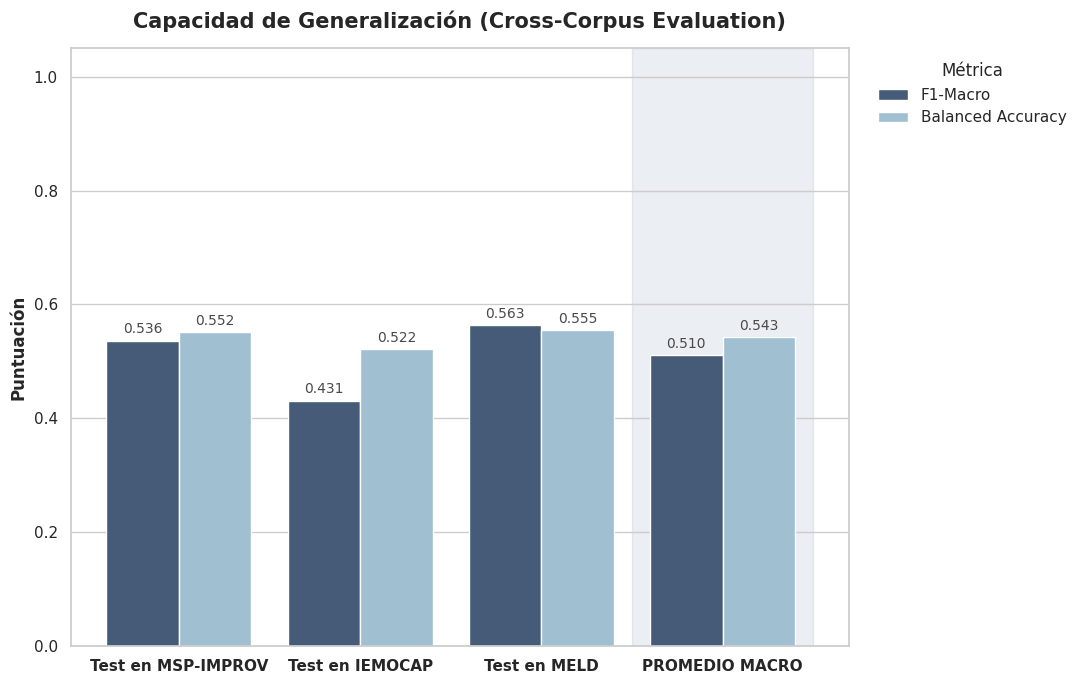

In [48]:
archivos_reportes = {
    'Test en MSP-IMPROV': 'resultados/transfer_learning/inter_multimodal/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MSP-IMPROV.txt',
    'Test en IEMOCAP': 'resultados/transfer_learning/inter_rotacion/reporte_pesos_modelo_estres_MELD_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_IEMOCAP.txt',
    'Test en MELD': 'resultados/transfer_learning/inter_rotacion/reporte_pesos_modelo_estres_IEMOCAP_MSP-IMPROV_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_transfer_learning_MELD.txt'
}

datos_rotacion = []
for nombre_eval, ruta in archivos_reportes.items():
    f1, ba, auc, recall = extraer_metricas_txt(ruta)
    datos_rotacion.append([nombre_eval, f1, ba, auc, recall])

columnas = ['Corpus Excluido (Test)', 'F1-Macro', 'Balanced Accuracy', 'ROC-AUC', 'Recall (Estrés)']
df_rotacion = pd.DataFrame(datos_rotacion, columns=columnas)

# Calculamos el promedio:
promedios = df_rotacion.mean(numeric_only=True)
fila_promedio = pd.DataFrame([['PROMEDIO MACRO', promedios['F1-Macro'], promedios['Balanced Accuracy'], promedios['ROC-AUC'], promedios['Recall (Estrés)']]], columns=columnas)

df_final = pd.concat([df_rotacion, fila_promedio], ignore_index=True)

df_final.to_csv('tabla_evaluacion_cruzada_automatica.csv', index=False)

def resaltar_promedio(row):
    if row['Corpus Excluido (Test)'] == 'PROMEDIO MACRO':
        return ['background-color: #dbeafe; font-weight: bold'] * len(row)
    return [''] * len(row)

display(df_final.style.apply(resaltar_promedio, axis=1).format(precision=4))

# ---------------------- GRÁFICA ----------------------------
df_grafica = df_final[['Corpus Excluido (Test)', 'F1-Macro', 'Balanced Accuracy']]
df_melted = df_grafica.melt(id_vars='Corpus Excluido (Test)', var_name='Métrica', value_name='Puntuación')

plt.figure(figsize=(11, 7))
sns.set_theme(style="whitegrid")

colores = ['#3D5A80', '#98C1D9'] 

ax = sns.barplot(
    data=df_melted, 
    x='Corpus Excluido (Test)', 
    y='Puntuación', 
    hue='Métrica', 
    palette=colores,
    edgecolor='white',
    linewidth=1
)

etiquetas_x = [t.get_text() for t in ax.get_xticklabels()]
if 'PROMEDIO MACRO' in etiquetas_x:
    idx_final = etiquetas_x.index('PROMEDIO MACRO')
    ax.axvspan(idx_final - 0.5, idx_final + 0.5, color='#3D5A80', alpha=0.10, zorder=0)

plt.title('Capacidad de Generalización (Cross-Corpus Evaluation)', fontsize=15, fontweight='bold', pad=15)
plt.ylim(0, 1.05)
plt.ylabel('Puntuación', fontsize=12, fontweight='bold')
plt.xlabel('', fontsize=12)

plt.xticks(fontsize=11, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10, color='#4a4a4a')

plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False) 
plt.tight_layout()

plt.savefig('Fig_Resultados_rotacion_Transferencia_Aprendizaje.png', dpi=300, bbox_inches='tight')
plt.show()